# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?


In [1]:
import pandas as pd

df = pd.read_csv(
    '/content/crx.data',
    header=None,
    na_values='?',
    names=[
        'A0', 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
        'A11', 'A12', 'A13', 'A14', 'A15'
        ]
    )

df.sample(5)

,A0,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15
304,a,24.75,13.665,u,g,q,h,1.500,f,f,0,f,g,280.0,1,-
31,b,42.00,9.790,u,g,x,h,7.960,t,t,8,f,g,0.0,0,+
562,b,23.33,1.500,u,g,c,h,1.415,t,f,0,f,g,422.0,200,+
366,a,22.75,6.165,u,g,aa,v,0.165,f,f,0,f,g,220.0,1000,-
445,a,NaN,11.250,u,g,ff,ff,0.000,f,f,0,f,g,NaN,5200,-


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A0      678 non-null    object 
 1   A1      678 non-null    float64
 2   A2      690 non-null    float64
 3   A3      684 non-null    object 
 4   A4      684 non-null    object 
 5   A5      681 non-null    object 
 6   A6      681 non-null    object 
 7   A7      690 non-null    float64
 8   A8      690 non-null    object 
 9   A9      690 non-null    object 
 10  A10     690 non-null    int64  
 11  A11     690 non-null    object 
 12  A12     690 non-null    object 
 13  A13     677 non-null    float64
 14  A14     690 non-null    int64  
 15  A15     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [3]:
df.describe()

,A1,A2,A7,A10,A13,A14
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [4]:
df.describe(include='object')

,A0,A3,A4,A5,A6,A8,A9,A11,A12,A15
count,678,684,684,681,681,690,690,690,690,690
unique,2,3,3,14,9,2,2,2,3,2
top,b,u,g,c,v,t,f,f,g,-
freq,468,519,519,137,399,361,395,374,625,383


¿Hay valores fuera de rango o imposibles, según el dominio del problema?: Parece que no.

¿Hay variables que no varían?: No

Qué variables cualitativas tienen muchos valores únicos (alta cardinalidad)?: Ninguna

¿Hay claves primarias o identificadores únicos?: No

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

In [5]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


In [6]:
df.isnull().sum()*100/df.shape[0]

,0
A0,1.739130
A1,1.739130
A2,0.000000
A3,0.869565
A4,0.869565
A5,1.304348
A6,1.304348
A7,0.000000
A8,0.000000
A9,0.000000


In [7]:
cat_vars = df.select_dtypes(include='object').columns.tolist()

for var in cat_vars:
  print('\n')
  print(f'{var}: {df[var].unique()}')



A0: ['b' 'a' nan]


A3: ['u' 'y' nan 'l']


A4: ['g' 'p' nan 'gg']


A5: ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan]


A6: ['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n']


A8: ['t' 'f']


A9: ['t' 'f']


A11: ['f' 't']


A12: ['g' 's' 'p']


A15: ['+' '-']


¿Qué variables tienen valores nulos? ¿En qué proporción?

¿Hay registros duplicados?: No

¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?: No

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

array([[<Axes: title={'center': 'A1'}>, <Axes: title={'center': 'A2'}>],
       [<Axes: title={'center': 'A7'}>, <Axes: title={'center': 'A10'}>],
       [<Axes: title={'center': 'A13'}>, <Axes: title={'center': 'A14'}>]],
      dtype=object)

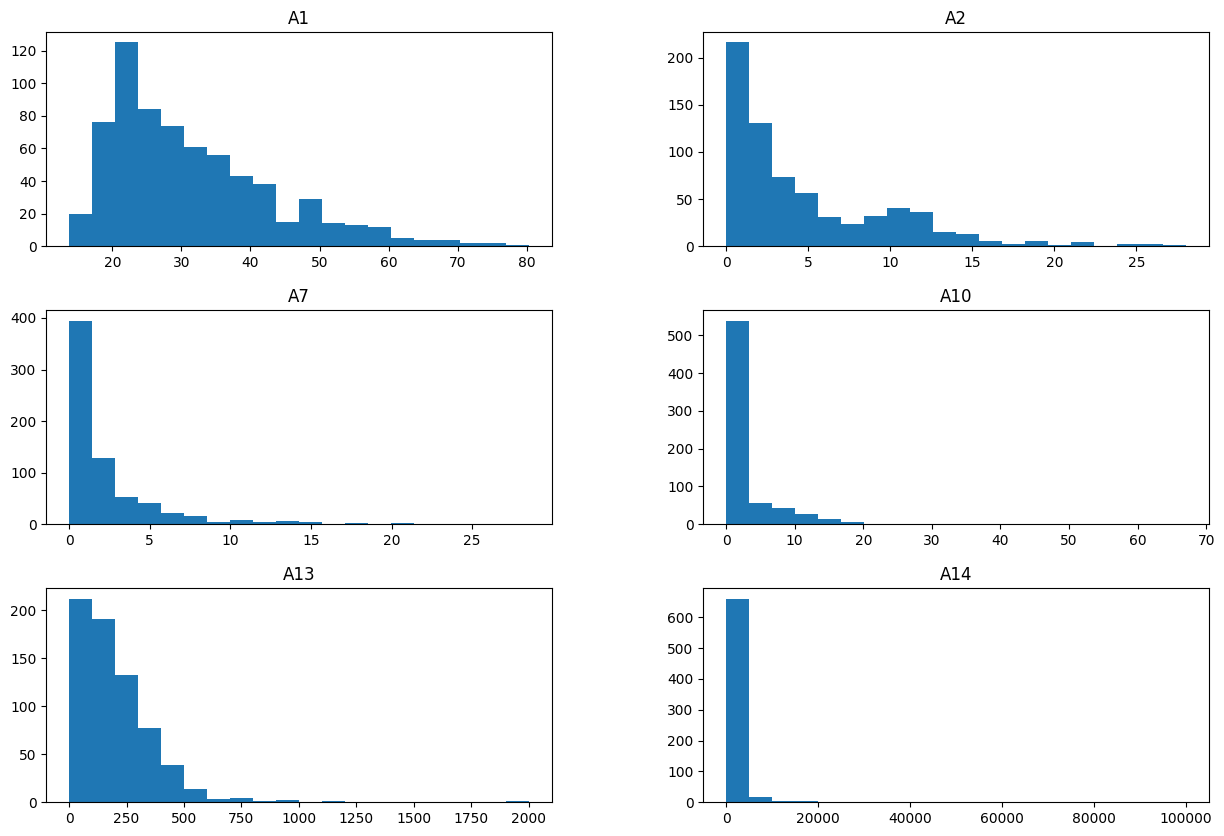

In [8]:
df.hist(figsize=(15, 10), bins=20, grid=False)

In [9]:
# Verificar supuesto de normalidad con prueba de Kolmogorov-Smirnov

from scipy.stats import kstest

df1 = df.dropna().copy()

num_vars = df1.select_dtypes(include='number').columns.tolist()

for num in num_vars:
    __, p_value = kstest(df1[num], 'norm', args=(df1[num].mean(), df1[num].std()))
    print(f"Prueba de Kolmogorov-Smirnov para {num}:")
    print(f"  Valor p: {p_value}")
    if p_value > 0.05:
        print(f"  {num} parece ser normal (no se rechaza la hipótesis nula)")
    else:
        print(f"  {num} no parece ser normal (se rechaza la hipótesis nula)")
    print()

Prueba de Kolmogorov-Smirnov para A1:
  Valor p: 1.774610273780338e-07
  A1 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A2:
  Valor p: 6.114602954076043e-18
  A2 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A7:
  Valor p: 2.895675213497347e-37
  A7 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A10:
  Valor p: 3.1420684831757564e-55
  A10 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A13:
  Valor p: 6.10926426296652e-12
  A13 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A14:
  Valor p: 9.776750165696906e-107
  A14 no parece ser normal (se rechaza la hipótesis nula)



,0
A1,"Axes(0.125,0.53;0.227941x0.35)"
A2,"Axes(0.398529,0.53;0.227941x0.35)"
A7,"Axes(0.672059,0.53;0.227941x0.35)"
A10,"Axes(0.125,0.11;0.227941x0.35)"
A13,"Axes(0.398529,0.11;0.227941x0.35)"
A14,"Axes(0.672059,0.11;0.227941x0.35)"


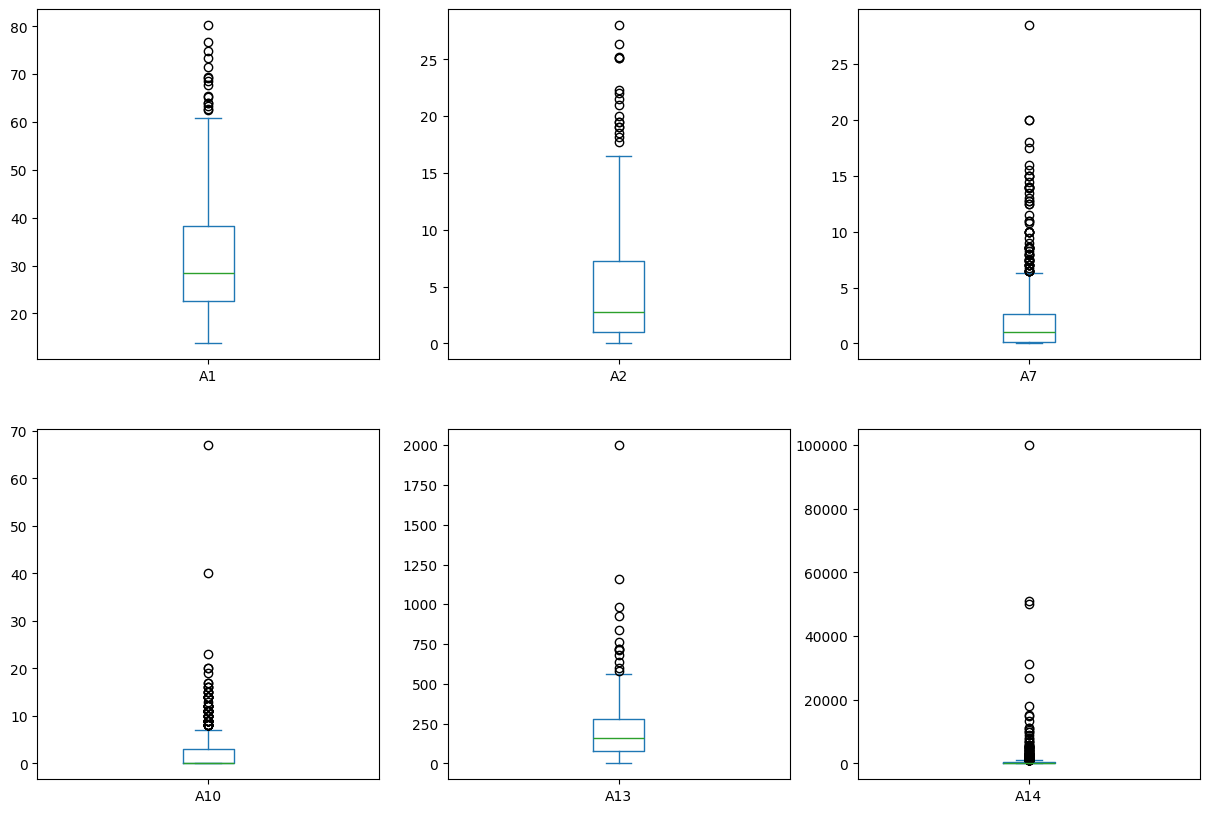

In [10]:
df.plot(kind='box', figsize=(15, 10), subplots=True, sharex=False, sharey=False, layout=(2, 3))

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no: Ninguna cumple con el supuesto de normalidad.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos: Todas tienen outliers.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [11]:
for var in cat_vars:
  print('\n')
  print(df[var].value_counts())



A0
b    468
a    210
Name: count, dtype: int64


A3
u    519
y    163
l      2
Name: count, dtype: int64


A4
g     519
p     163
gg      2
Name: count, dtype: int64


A5
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64


A6
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64


A8
t    361
f    329
Name: count, dtype: int64


A9
f    395
t    295
Name: count, dtype: int64


A11
f    374
t    316
Name: count, dtype: int64


A12
g    625
s     57
p      8
Name: count, dtype: int64


A15
-    383
+    307
Name: count, dtype: int64


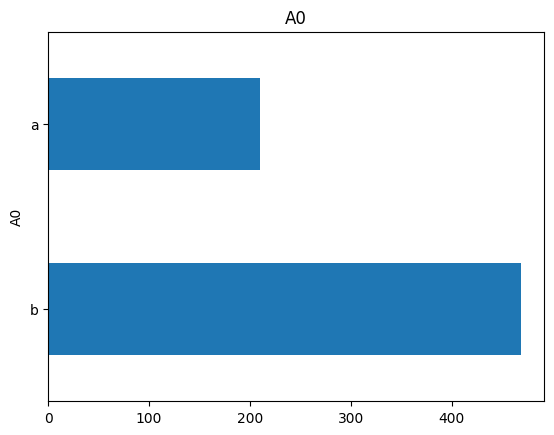

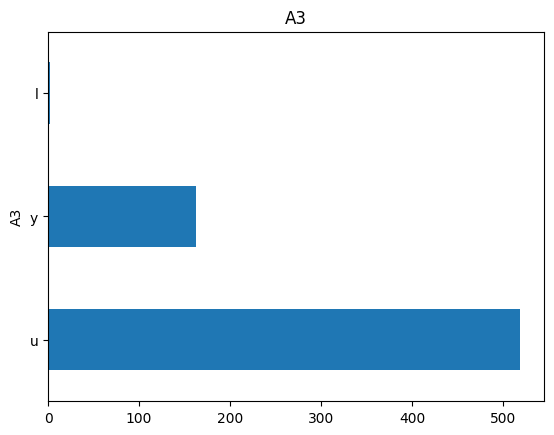

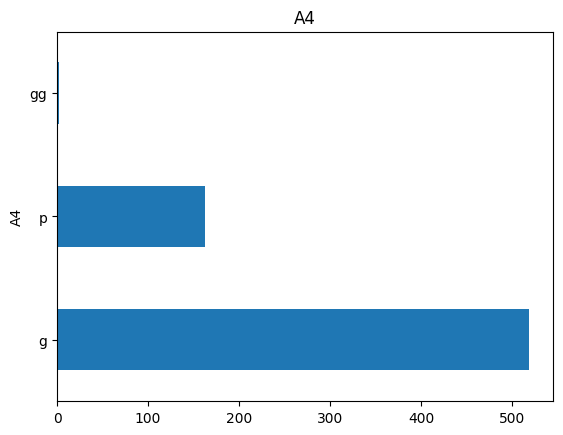

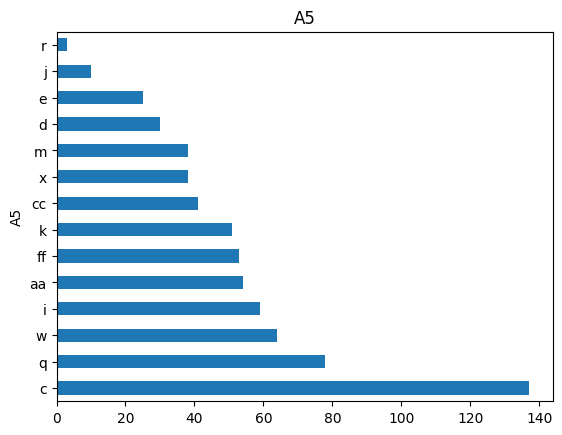

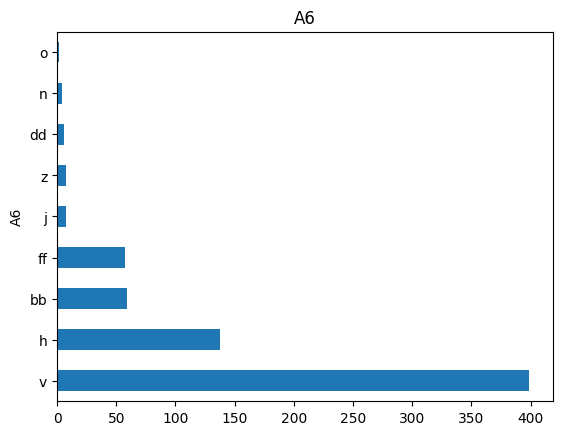

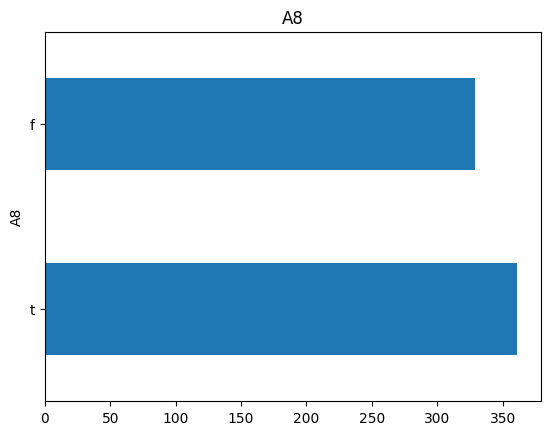

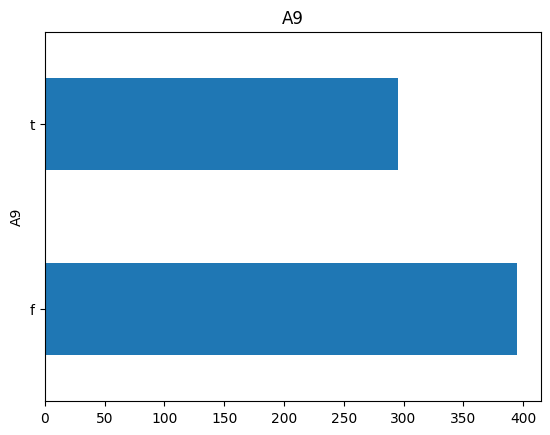

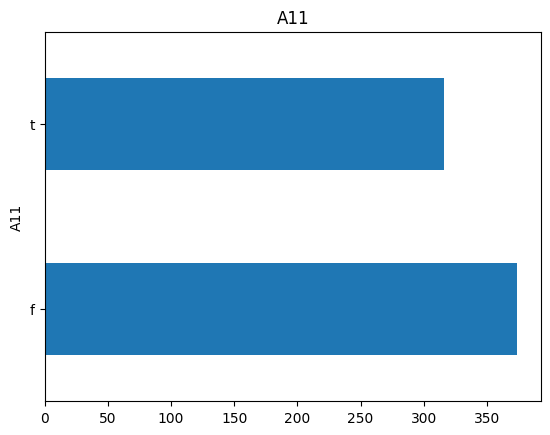

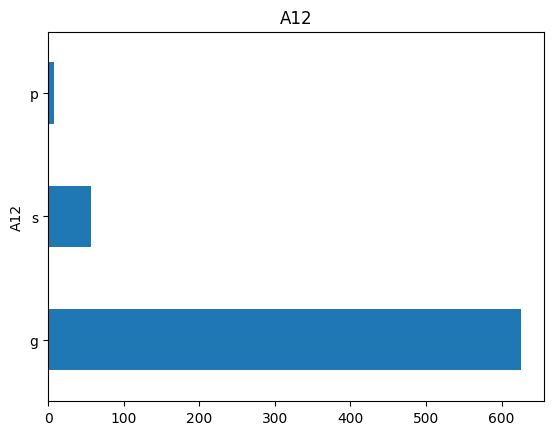

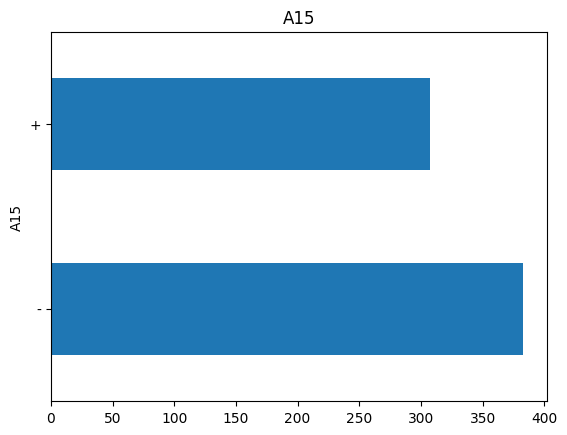

In [12]:
import matplotlib.pyplot as plt

for var in cat_vars:
  df[var].value_counts().plot(kind='barh')
  plt.title(var)
  plt.show()


Se descartarían A1, A13.

¿Existen variables de alta cardinalidad?: No

¿Existen categorías atípicas?: A3, A4, A5, A6 y A12 tienen categorías atípicas

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la variable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?


<Figure size 640x480 with 0 Axes>

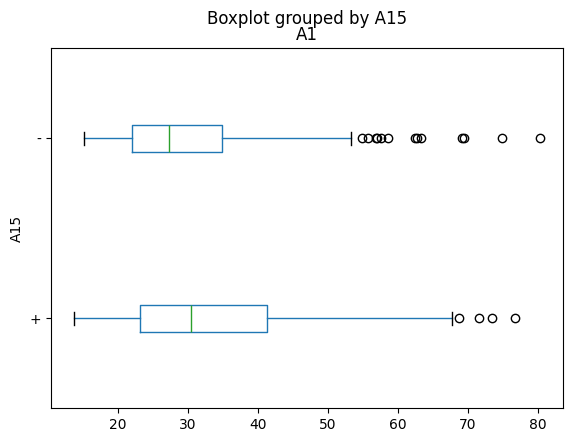

<Figure size 640x480 with 0 Axes>

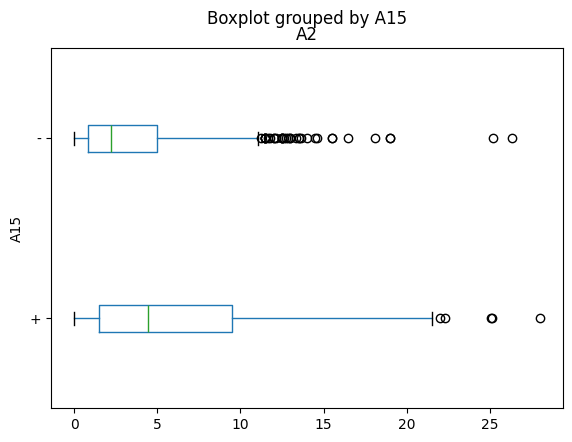

<Figure size 640x480 with 0 Axes>

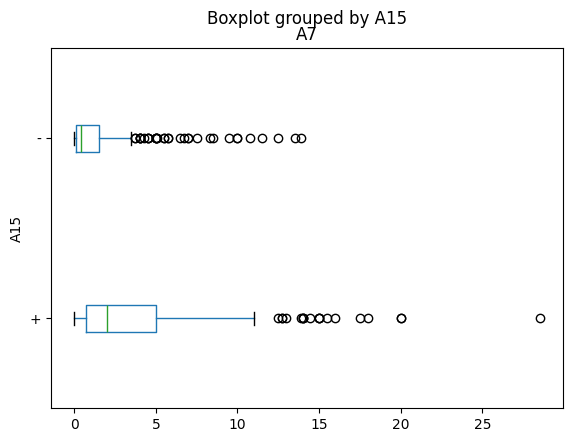

<Figure size 640x480 with 0 Axes>

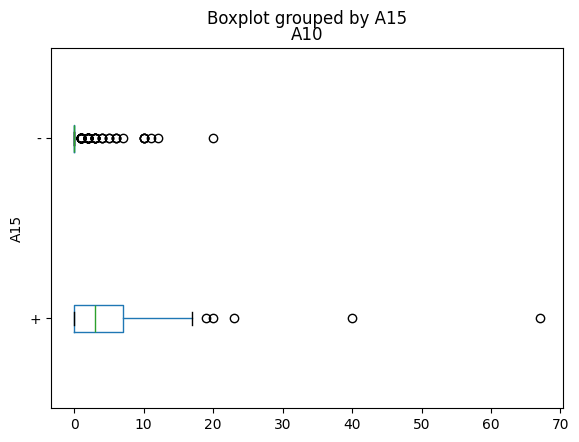

<Figure size 640x480 with 0 Axes>

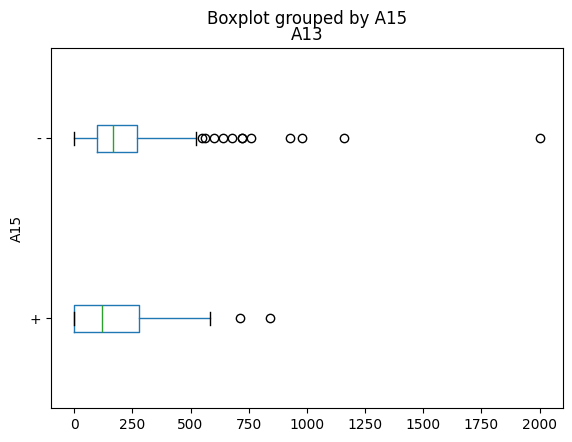

<Figure size 640x480 with 0 Axes>

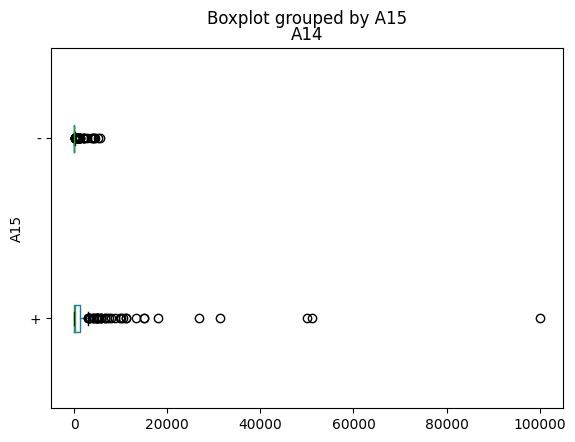

In [13]:
for var in num_vars:
  plt.figure()
  df.boxplot(by='A15', column=var, grid=False, vert=False)
  plt.title(var)
  plt.show()

In [19]:
df.groupby('A15').describe().T

A15                    +            -
A1  count     305.000000   373.000000
    mean       33.720492    29.808231
    std        12.809641    10.919291
    min        13.750000    15.170000
    25%        23.170000    22.000000
    50%        30.500000    27.330000
    75%        41.330000    34.830000
    max        76.750000    80.250000
A2  count     307.000000   383.000000
    mean        5.904951     3.839948
    std         5.471485     4.337662
    min         0.000000     0.000000
    25%         1.500000     0.835000
    50%         4.460000     2.210000
    75%         9.520000     5.000000
    max        28.000000    26.335000
A7  count     307.000000   383.000000
    mean        3.427899     1.257924
    std         4.120792     2.120481
    min         0.000000     0.000000
    25%         0.750000     0.125000
    50%         2.000000     0.415000
    75%         5.000000     1.500000
    max        28.500000    13.875000
A10 count     307.000000   383.000000
    mean        4.605863     0.631854
    std         6.320242     1.900049
    min         0.000000     0.000000
    25%         0.000000     0.000000
    50%         3.000000     0.000000
    75%         7.000000     0.000000
    max        67.000000    20.000000
A13 count     301.000000   376.000000
    mean      164.421927   199.699468
    std       161.770675   181.564835
    min         0.000000     0.000000
    25%         0.000000   100.000000
    50%       120.000000   167.500000
    75%       280.000000   272.000000
    max       840.000000  2000.000000
A14 count     307.000000   383.000000
    mean     2038.859935   198.605744
    std      7659.763941   671.608839
    min         0.000000     0.000000
    25%         0.000000     0.000000
    50%       221.000000     1.000000
    75%      1209.000000    67.000000
    max    100000.000000  5552.000000

Buenas predictoras: Todas menos A1 y A13.

In [14]:
cat_vars = df.select_dtypes(include='object').columns
print(cat_vars)

Index(['A0', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12', 'A15'], dtype='object')


In [15]:
print(cat_vars)

Index(['A0', 'A3', 'A4', 'A5', 'A6', 'A8', 'A9', 'A11', 'A12', 'A15'], dtype='object')


In [16]:
for var in cat_vars:
  tabla = pd.crosstab(
      df[var],
      df['A15'],
      normalize='index'
      )

  print('\n')
  print(f'{var}:')
  print(tabla)



A0:
A15         +         -
A0                     
a    0.466667  0.533333
b    0.440171  0.559829


A3:
A15         +         -
A3                     
l    1.000000  0.000000
u    0.493256  0.506744
y    0.276074  0.723926


A4:
A15         +         -
A4                     
g    0.493256  0.506744
gg   1.000000  0.000000
p    0.276074  0.723926


A5:
A15         +         -
A5                     
aa   0.351852  0.648148
c    0.452555  0.547445
cc   0.707317  0.292683
d    0.233333  0.766667
e    0.560000  0.440000
ff   0.132075  0.867925
i    0.237288  0.762712
j    0.300000  0.700000
k    0.274510  0.725490
m    0.421053  0.578947
q    0.653846  0.346154
r    0.666667  0.333333
w    0.515625  0.484375
x    0.842105  0.157895


A6:
A15         +         -
A6                     
bb   0.423729  0.576271
dd   0.333333  0.666667
ff   0.140351  0.859649
h    0.630435  0.369565
j    0.375000  0.625000
n    0.500000  0.500000
o    0.500000  0.500000
v    0.423559  0.576441
z    0.750

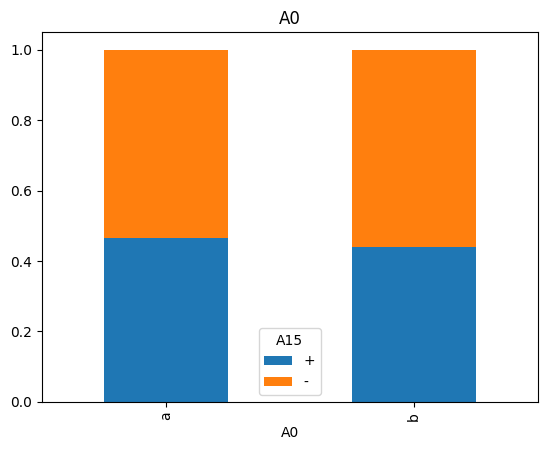

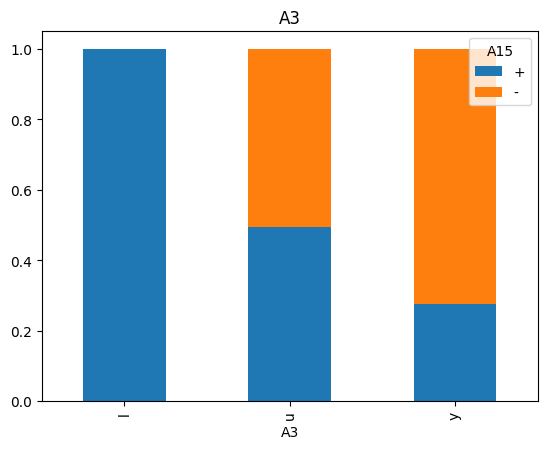

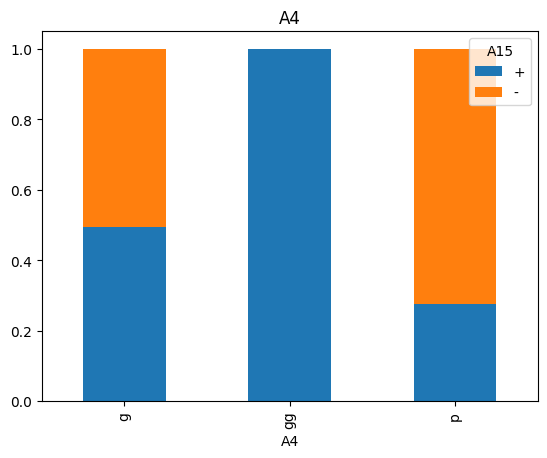

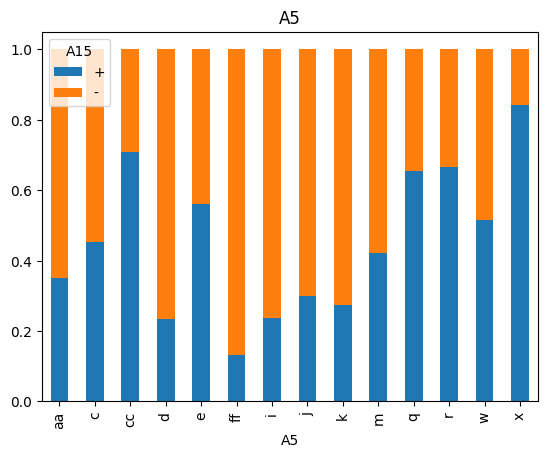

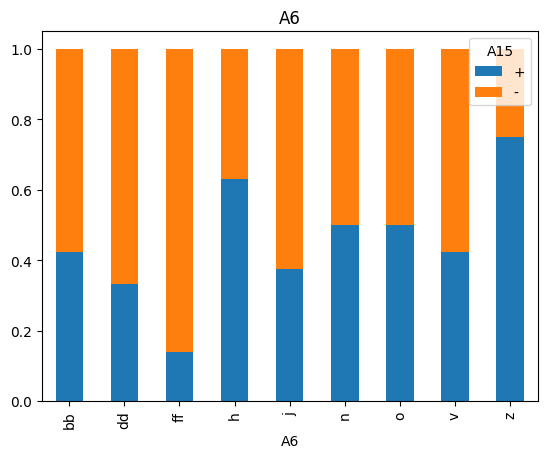

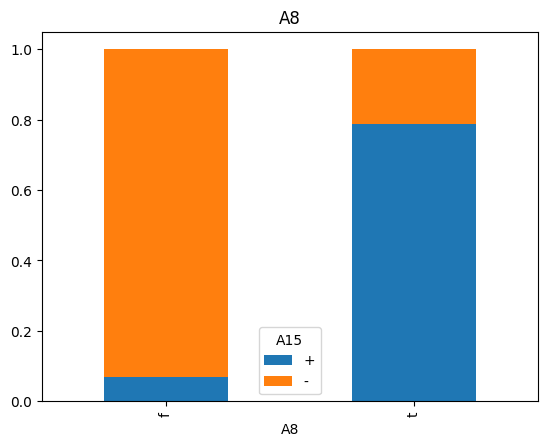

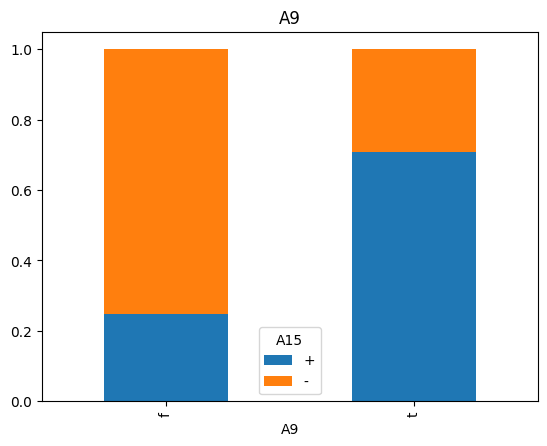

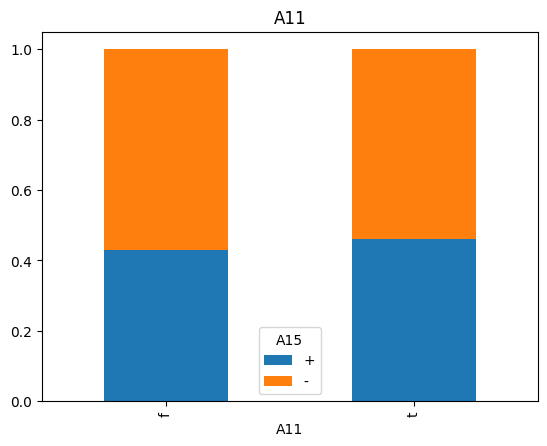

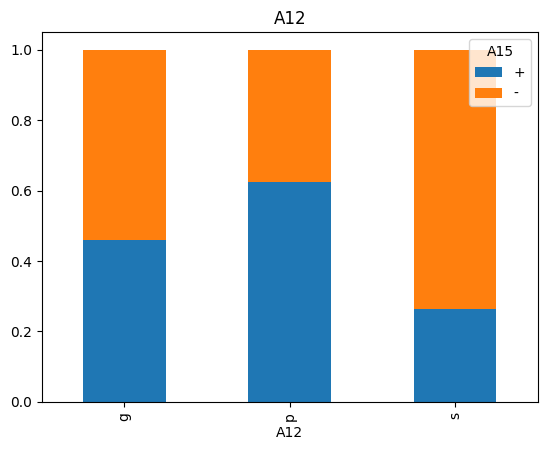

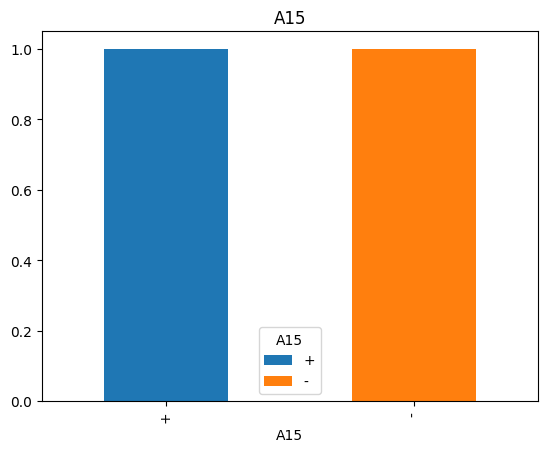

In [17]:
for var in cat_vars:
  tabla = pd.crosstab(df[var], df['A15'], normalize='index')
  tabla.plot(kind='bar', stacked=True)
  plt.title(var)
  plt.show()

Buenas predictoras: Todas exceptuando A0 y A11.